# 📡 LAB TOOLS &mdash; Análise Espectral

---
Copyright (C) 2026 Roberto Baginski Batista Santos - Prof.Baginski@gmail.com

Este programa é um software livre; você pode redistribuí-lo e/ou
modificá-lo sob os termos da Licença Pública Geral GNU como publicada
pela Free Software Foundation; tanto a versão 3 da Licença, ou
(a seu critério) qualquer versão posterior.

Este programa é distribuído na expectativa de que seja útil,
mas SEM NENHUMA GARANTIA; sem mesmo a garantia implícita de
COMERCIALIZAÇÃO ou de ADEQUAÇÃO A QUALQUER PROPÓSITO EM PARTICULAR.
Veja a Licença Pública Geral GNU para mais detalhes.

Você deve ter recebido uma cópia da Licença Pública Geral GNU junto
com este programa. Se não, veja https://www.gnu.org/licenses/gpl-3.0.html.

---
Esta ferramenta determina o **espectro de frequências** de uma série temporal real $x(t)$, definida no intervalo $[T,\,T+\tau]$, usando a **Transformada Rápida de Fourier (FFT)** e os métodos de análise espectral da biblioteca **SciPy**.

A amostragem **não precisa ser uniforme**; se os intervalos temporais entre amostras sucessivas não forem constantes, a ferramenta interpola automaticamente a série para uma grade de tempo uniforme antes de calcular o espectro.

---
### Fundamentos

A tranformada de Fourier (contínua) $X(f)$ da função $x(t)$ é aproximada numericamente por

$$X(f) \approx \Delta t \sum_{n=0}^{N-1} x_n\, e^{-i 2\pi f\, n\Delta t} = \Delta t \cdot \text{FFT}[x(t)]$$

e, usando uma representação **unilateral** (apenas $f\ge 0$, já que $x(t)$ é real e o espectro bilateral é simétrico — as componentes com $f>0$ são multiplicadas por 2, exceto a componente DC e, se existir, a de Nyquist, para preservar a energia total do sinal), são apresentados os seguintes gráficos, em função da frequência $f$:

| Gráfico | Expressão | Escala do gráfico |
|---|---|---|
| Espectro | $\lvert X(f)\rvert$ | linear |
| Espectro de magnitude | $\lvert X(f)\rvert/\tau$ | linear |
| Densidade espectral de amplitude | $\lvert X(f)\rvert/\sqrt{\tau}$ | linear |
| Densidade espectral de energia (ESD) | $\lvert X(f)\rvert^2$ | **log** |
| Densidade espectral de potência (PSD) | estimada via `scipy.signal.welch` | **log** |

Como estimador robusto, a **PSD é calculada pelo método de Welch** (periodograma médio com janelas sobrepostas), em vez de $\lvert X(f)\rvert^2/\tau$ calculado diretamente da FFT — o que reduz a variância da estimativa, ao custo de menor resolução em frequência.

**Gráficos adicionais** também são apresentados, por serem úteis na interpretação de séries temporais:
- **Fase de $X(f)$** — mostra a defasagem de cada componente de frequência, informação perdida nos gráficos de magnitude/potência.
- **Espectrograma (STFT)** — mostra como o conteúdo espectral evolui ao longo do tempo, revelando eventuais fenômenos não-estacionários que o espectro global não conseguiria capturar.

---
### Amostragem não-uniforme

Quando os intervalos de tempo entre amostras sucessivas não são todos iguais, a série é reamostrada (por interpolação **linear** ou por **spline cúbica**, à escolha do usuário) para uma grade de tempo uniforme, com passo $\Delta t$ escolhido automaticamente (mediana ou menor intervalo observado) ou definido manualmente. Essa reamostragem é necessária tanto para o cálculo direto da FFT quanto para o `scipy.signal.welch`, que exige amostragem uniforme.

O gráfico de $x(t)$ mostra, quando aplicável, tanto as amostras originais (não-uniformes) quanto a série reamostrada, para transparência do processo.

---
**Como usar:**
Execute a **Célula 1** — a interface aparece logo abaixo.

---
### Formatos de arquivo aceitos

| Formato | Extensão |
|---|---|
| XLSX - Planilha do Excel | `.xlsx` |
| CSV - Valores separados por vírgula | `.csv` `.txt` |

Cada linha do arquivo deve conter os valores de tempo e do sinal (em colunas), na ordem que o usuário indicar na interface. Os valores numéricos podem usar `.` ou `,` como separador decimal.

Para indicar os rótulos (nomes ou símbolos das grandezas) e as unidades, use cabeçalhos de coluna como `Tempo (s)` ou `Tensão (V)`, ou a palavra-chave `#unidades:` seguida de valores separados por `,` ou `;`, em uma linha de comentário antes dos dados.

A unidade de tempo do arquivo pode ser configurada na interface (s, ms, µs, min, h); internamente, todos os cálculos de frequência usam segundos, de modo que $f$ é sempre expressa em **Hz**.

---
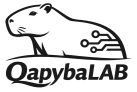

**https://github.com/rbaginski/QapybaLAB**

In [ ]:
#@title Execute esta célula para abrir a ferramenta **LAB TOOLS &mdash; Análise Espectral**
# ── Célula 1: análise espectral ────────────────────────────────
# A ferramenta foi especificada pelo licenciante, incluindo métodos,
# pacotes a serem usados e linhas gerais da interface gráfica, mas a
# maior parte do código, especialmente as funções para leitura de
# arquivos e para a interface gráfica, foi escrita usando o modelo
# Claude Sonnet 5.0, reaproveitando os mecanismos de entrada de dados
# já validados em "Ajuste de Curvas". O código gerado foi inspecionado
# e sofreu alterações e correções realizadas pelo licenciante.

import math, io, re, base64, unicodedata, warnings
import numpy as np
from scipy.interpolate import CubicSpline
from scipy.signal import welch, spectrogram, get_window
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import ipywidgets as w
from IPython.display import display, HTML, clear_output

warnings.filterwarnings("ignore")
matplotlib.rcParams.update({
    "figure.dpi": 110,
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# ══════════════════════════════════════════════════════════════════
#  NORMALIZAÇÃO DE NOMES
#  remove acentos e outros diacríticos para uso em nomes de arquivo
# ══════════════════════════════════════════════════════════════════
def nome_para_arquivo(nome):
    """Converte nome com acentos/cedilha para versão segura para nomes
    de arquivo (ex: 'posição' → 'posicao')."""
    nfd = unicodedata.normalize("NFD", nome)
    return "".join(c for c in nfd
                   if unicodedata.category(c) != "Mn"
                   ).replace(" ", "_")

# ══════════════════════════════════════════════════════════════════
#  ESTILOS CSS
#  Convenção compartilhada por toda a suíte LAB/NEWTON TOOLS:
#    .sec   → rótulo de seção (cor = acento do app)
#    .rcard → card de resultado/destaque (cor = acento do app)
#    .gcard → card de "sucesso" (verde fixo)
#    .bcard → card informativo secundário (azul fixo)
#    .wcard → card de aviso (laranja fixo)
#    .ecard → card de erro (vermelho fixo)
#    .icard → card informativo auxiliar (violeta fixo)
#    .res-t → tabela de dados (cabeçalho azul-marinho fixo)
#  Acento desta ferramenta: azul #3b5bdb (LAB TOOLS genérico)
# ══════════════════════════════════════════════════════════════════
display(HTML("""
<style>
.sec{font-weight:700;font-size:.75rem;letter-spacing:.08em;color:#3b5bdb;
  text-transform:uppercase;margin:13px 0 3px;}
.rcard{background:#f0f4ff;border-left:4px solid #3b5bdb;border-radius:6px;
  padding:9px 15px;margin:5px 0;font-family:monospace;font-size:.91rem;}
.gcard{background:#f0fff4;border-left:4px solid #2f9e44;border-radius:6px;
  padding:9px 15px;margin:5px 0;font-size:.91rem;}
.bcard{background:#f0f4ff;border-left:4px solid #3b5bdb;border-radius:6px;
  padding:9px 15px;margin:5px 0;font-family:monospace;font-size:.91rem;}
.wcard{background:#fff9db;border-left:4px solid #e67700;border-radius:6px;
  padding:9px 15px;margin:5px 0;font-size:.91rem;}
.ecard{background:#fff0f0;border-left:4px solid #c92a2a;border-radius:6px;
  padding:9px 15px;margin:5px 0;font-size:.91rem;}
.icard{background:#f3f0ff;border-left:4px solid #7048e8;border-radius:6px;
  padding:9px 15px;margin:5px 0;font-size:.88rem;}
.res-t{border-collapse:collapse;font-size:.83rem;width:60%;margin:6px 0;}
.res-t th{background:#1a1a2e;color:#fff;padding:5px 10px;text-align:left;}
.res-t td{padding:4px 10px;text-align:left;border-bottom:1px solid #eee;
  font-family:monospace;}
.res-t tr:nth-child(odd) td{text-align:left}
.res-t tr:nth-child(even) td{background:#eafcff;text-align:left}
</style>
"""))

# ══════════════════════════════════════════════════════════════════
#  METADADOS / TEXTO
# ══════════════════════════════════════════════════════════════════
def eh_numero(s):
    """Verifica se uma string representa um número (aceita ',' decimal)."""
    try:
        float(str(s).replace(',', '.'))
        return True
    except (ValueError, AttributeError):
        return False

def parse_rotulo_unidade(texto):
    """Extrai rótulo e unidade de uma string de cabeçalho, ex.:
    'Tensão (V)' -> ('Tensão','V')   |   'tempo' -> ('tempo','')"""
    texto=str(texto).strip()
    m=re.match(r'^(.*?)\s*\(([^()]*)\)\s*$', texto)
    if m and m.group(1).strip():
        return m.group(1).strip(), m.group(2).strip()
    return texto, ''

def extrair_metadados(linha_str):
    """Reconhece linhas de metadados do tipo:  # unidades: s, V
    Retorna (chave, [valores]) ou (None, None)."""
    s=str(linha_str).strip()
    if not s.startswith('#'): return None,None
    s=s.lstrip('#').strip()
    if ':' not in s: return None,None
    chave,resto=s.split(':',1)
    chave=chave.strip().lower()
    valores=[v.strip() for v in re.split(r'[,\t]',resto) if v.strip()!='']
    if not valores: return None,None
    if chave in ('unidades','unidade','units','unit'):
        return 'unidades',valores
    return None,None

# ══════════════════════════════════════════════════════════════════
#  LEITURA DE ARQUIVO
#  (mecanismo idêntico ao usado em "Ajuste de Curvas", simplificado
#   para duas colunas — tempo t e sinal x — sem incertezas)
# ══════════════════════════════════════════════════════════════════
def detectar_sep(texto):
    cnt={",":0,";":0,"\t":0}
    for l in texto.splitlines()[:10]:
        s=l.strip()
        if not s or s.startswith("#"): continue
        for sep in cnt: cnt[sep]+=s.count(sep)
    best=max(cnt,key=cnt.get)
    return best if cnt[best]>0 else " "

def ler_texto(texto,sep,ct,cx):
    linhas=[l for l in texto.splitlines()
            if l.strip() and not l.strip().startswith("#")]
    if not linhas: return None,["Arquivo sem dados."]
    tok=(linhas[0].split(sep) if sep!=" " else linhas[0].split())
    tem_cab=any(not t.strip().replace(",","").replace(".","",1)
                .lstrip("-").isdigit() for t in tok if t.strip())
    if tem_cab: linhas=linhas[1:]
    pontos=[]; erros=[]
    for i,linha in enumerate(linhas,1):
        ps=([p.strip() for p in linha.split(sep)] if sep!=" " else linha.split())
        try:
            def v(idx): return float(ps[idx].replace(",","."))
            t_=v(ct); x_=v(cx)
            pontos.append((t_,x_))
        except Exception as e: erros.append(f"Linha {i}: {e}")
    return (pontos or None),erros

def ler_xlsx(conteudo_bytes, ct, cx):
    """Lê dados (t, x) de um arquivo XLSX usando openpyxl."""
    try:
        import openpyxl
    except ImportError:
        return None, ["openpyxl não instalado. Execute: !pip install openpyxl"]
    try:
        wb = openpyxl.load_workbook(io.BytesIO(conteudo_bytes), data_only=True)
        ws = wb.active
    except Exception as e:
        return None, [f"Erro ao abrir XLSX: {e}"]

    linhas = []
    for row in ws.iter_rows(values_only=True):
        cells = [str(c).strip() if c is not None else '' for c in row]
        linha_str = '\t'.join(cells).strip()
        if not linha_str or linha_str.startswith('#'):
            continue
        linhas.append(cells)
    if not linhas:
        return None, ["Planilha sem dados."]

    primeira = linhas[0]
    tem_cab = any(c and not eh_numero(c) for c in primeira if c)
    dados = linhas[1:] if tem_cab else linhas

    pontos = []; erros = []
    for i, cells in enumerate(dados, 1):
        try:
            def v(idx):
                if idx >= len(cells) or cells[idx] == '':
                    raise IndexError(f"Coluna {idx+1} ausente")
                return float(cells[idx].replace(',', '.'))
            t_ = v(ct); x_ = v(cx)
            pontos.append((t_, x_))
        except Exception as e:
            erros.append(f"Linha {i}: {e}")
    return (pontos or None), erros

# ══════════════════════════════════════════════════════════════════
#  NÚCLEO NUMÉRICO — ANÁLISE ESPECTRAL
# ══════════════════════════════════════════════════════════════════
FATOR_S = {"s":1.0, "ms":1e-3, "µs":1e-6, "min":60.0, "h":3600.0}
JANELAS = {"Hann":"hann", "Hamming":"hamming",
           "Blackman":"blackman", "Retangular":"boxcar"}

N_MAX_UNIFORME = 400_000   # limite de segurança para a grade interpolada

def preparar_serie(t, x, fator_t):
    """Ordena por tempo, converte para segundos, remove duplicatas de
    tempo (mantendo a 1ª ocorrência). Retorna (t_s, x, avisos)."""
    t = np.asarray(t, dtype=float) * fator_t
    x = np.asarray(x, dtype=float)
    ordem = np.argsort(t, kind="stable")
    t, x = t[ordem], x[ordem]
    avisos = []
    dif = np.diff(t)
    if np.any(dif <= 0):
        manter = np.concatenate(([True], dif > 0))
        n_dup = int(np.sum(~manter))
        t, x = t[manter], x[manter]
        avisos.append(f"{n_dup} ponto(s) com tempo duplicado foram descartados "
                       f"(mantida a 1ª ocorrência).")
    return t, x, avisos

def diagnosticar_amostragem(t):
    """Retorna (uniforme?, dt_estimado, cv) a partir dos intervalos."""
    dif = np.diff(t)
    dt_med = float(np.median(dif))
    cv = float(dif.std()/dif.mean()) if dif.mean() != 0 else 0.0
    uniforme = cv < 1e-6
    return uniforme, dt_med, cv, dif

def interpolar_uniforme(t, x, dt, metodo):
    """Reamostra (t,x) — não necessariamente uniforme — para uma grade
    uniforme de passo dt, usando interpolação linear ou spline cúbica."""
    N = int(np.floor((t[-1]-t[0])/dt)) + 1
    N = max(N, 2)
    t_u = t[0] + np.arange(N)*dt
    if metodo.startswith("Cúbica"):
        cs = CubicSpline(t, x)
        x_u = cs(t_u)
    else:
        x_u = np.interp(t_u, t, x)
    return t_u, x_u

def calcular_nperseg(N, valor_usuario):
    if valor_usuario and valor_usuario > 0:
        return int(min(valor_usuario, N))
    return int(min(256, max(8, N)))

def espectro_fft_unilateral(x_u, dt):
    """X(f) = dt · rfft(x)  (aproximação da Transformada de Fourier
    contínua), convertido para representação unilateral (apenas
    frequências ≥ 0), dobrando a amplitude das componentes que não são
    DC nem Nyquist para preservar a energia total do sinal real."""
    N = len(x_u)
    X = np.fft.rfft(x_u) * dt
    freqs = np.fft.rfftfreq(N, dt)
    Xos = X.copy()
    if N % 2 == 0:
        Xos[1:-1] *= 2.0   # exclui DC (0) e Nyquist (última componente)
    else:
        Xos[1:] *= 2.0     # exclui apenas DC; não há Nyquist exato
    return freqs, Xos

def analisar_espectro(t, x, fator_t, metodo_interp, dt_modo, dt_manual,
                       janela, nperseg_usuario, overlap_pct):
    """Executa o pipeline completo: preparo → (interpolação, se
    necessário) → FFT unilateral → Welch (PSD) → espectrograma."""
    avisos = []
    t_s, x, av = preparar_serie(t, x, fator_t)
    avisos += av
    if len(t_s) < 8:
        raise ValueError(f"São necessários pelo menos 8 pontos válidos "
                          f"({len(t_s)} fornecidos).")

    uniforme, dt_auto_med, cv, dif = diagnosticar_amostragem(t_s)
    dt_auto_min = float(dif.min())

    precisa_interp = (not uniforme) or (dt_modo == "Manual")
    if dt_modo == "Manual":
        dt_alvo = dt_manual * fator_t
        if dt_alvo <= 0:
            raise ValueError("Δt manual deve ser positivo.")
    elif dt_modo.startswith("Automático (menor"):
        dt_alvo = dt_auto_min
    else:
        dt_alvo = dt_auto_med

    if precisa_interp:
        N_estimado = int(np.floor((t_s[-1]-t_s[0])/dt_alvo)) + 1
        if N_estimado > N_MAX_UNIFORME:
            raise ValueError(
                f"A interpolação geraria {N_estimado:,} amostras (limite "
                f"{N_MAX_UNIFORME:,}). Escolha um Δt maior ou o modo "
                f"'mediana'.".replace(",", "."))
        t_u, x_u = interpolar_uniforme(t_s, x, dt_alvo, metodo_interp)
        dt = float(t_u[1]-t_u[0])
    else:
        t_u, x_u = t_s, x
        dt = float(np.mean(dif))

    N = len(x_u)
    tau = float(t_u[-1]-t_u[0])
    fs = 1.0/dt

    freqs, Xos = espectro_fft_unilateral(x_u, dt)
    mag = np.abs(Xos)
    espectro       = mag
    espectro_mag   = mag/tau
    dens_amplitude = mag/np.sqrt(tau)
    esd            = mag**2
    fase           = np.angle(Xos)

    janela_scipy = JANELAS.get(janela, "hann")
    nperseg = calcular_nperseg(N, nperseg_usuario)
    noverlap = int(nperseg * np.clip(overlap_pct,0,95)/100.0)
    noverlap = min(noverlap, nperseg-1)

    f_w, Pxx = welch(x_u, fs=fs, window=janela_scipy,
                      nperseg=nperseg, noverlap=noverlap, scaling="density")

    nperseg_sg = min(nperseg, N)
    noverlap_sg = min(noverlap, nperseg_sg-1)
    f_sg, t_sg, Sxx = spectrogram(x_u, fs=fs, window=janela_scipy,
                                   nperseg=nperseg_sg, noverlap=noverlap_sg)
    t_sg = t_sg + t_u[0]   # realinha ao tempo absoluto (T, T+τ)

    resultado = dict(
        t_original=t_s, x_original=x, t_u=t_u, x_u=x_u,
        uniforme=uniforme, cv=cv, dt_auto_med=dt_auto_med,
        dt_auto_min=dt_auto_min, precisa_interp=precisa_interp,
        metodo_interp=metodo_interp, dt=dt, N=N, tau=tau, fs=fs,
        freqs=freqs, espectro=espectro, espectro_mag=espectro_mag,
        dens_amplitude=dens_amplitude, esd=esd, fase=fase,
        f_welch=f_w, psd=Pxx, nperseg=nperseg, noverlap=noverlap,
        f_spec=f_sg, t_spec=t_sg, Sxx=Sxx, janela=janela, avisos=avisos,
    )
    return resultado

# ══════════════════════════════════════════════════════════════════
#  GRÁFICO MATPLOTLIB → PNG base64 → HTML <img>
# ══════════════════════════════════════════════════════════════════
def fig_para_html(res, lt, ux, lx):
    t_orig, x_orig = res["t_original"], res["x_original"]
    t_u, x_u = res["t_u"], res["x_u"]
    freqs = res["freqs"]
    tau, N, dt, fs = res["tau"], res["N"], res["dt"], res["fs"]

    ut_x = f" [{ux}·s]" if ux else ""
    ut_mag = f" [{ux}]" if ux else ""
    ut_amp = f" [{ux}·√s]" if ux else ""
    ut_esd = f" [{ux}²·s²]" if ux else ""
    ut_psd = f" [{ux}²·s]" if ux else ""
    ux_lbl = f" ({ux})" if ux else ""

    fig = plt.figure(figsize=(13.5, 17))
    gs = gridspec.GridSpec(4, 3, height_ratios=[1.05, 1, 1, 1.25],
                            hspace=0.5, wspace=0.34,
                            left=.07, right=.97, top=.965, bottom=.035)

    CP, CF = "#1f77b4", "#3b5bdb"

    # ── (1) x(t) vs t ──────────────────────────────────────────────
    ax0 = fig.add_subplot(gs[0, :])
    if res["precisa_interp"]:
        ax0.plot(t_orig, x_orig, "o", ms=3, color="#aab4d4", alpha=.6,
                  label="Amostras originais (não-uniformes)", zorder=2)
        ax0.plot(t_u, x_u, "-", color=CF, lw=1.2,
                  label=f"Reamostrado (uniforme, {res['metodo_interp']})", zorder=3)
        ax0.legend(fontsize=8, loc="best", framealpha=.88)
    else:
        ax0.plot(t_u, x_u, "-o", color=CF, ms=3, lw=1.1)
    ax0.set_xlabel(f"{lt} (s)", fontsize=10)
    ax0.set_ylabel(f"{lx}{ux_lbl}", fontsize=10)
    ax0.set_title(f"{lx}({lt})  —  N={N}   τ={tau:.5g} s   "
                   f"Δt={dt:.5g} s   fs={fs:.5g} Hz", fontsize=10)
    ax0.grid(True, ls="--", alpha=.4); ax0.set_facecolor("#fafafa")

    # ── (2) Espectro |X(f)| ──────────────────────────────────────
    ax1 = fig.add_subplot(gs[1, 0])
    ax1.plot(freqs, res["espectro"], color=CF, lw=1.0)
    ax1.set_title("Espectro  |X(f)|", fontsize=9.5)
    ax1.set_xlabel("f (Hz)", fontsize=9); ax1.set_ylabel(f"|X(f)|{ut_x}", fontsize=9)
    ax1.grid(True, ls="--", alpha=.4); ax1.set_facecolor("#fafafa")

    # ── (3) Espectro de magnitude |X(f)|/τ ───────────────────────
    ax2 = fig.add_subplot(gs[1, 1])
    ax2.plot(freqs, res["espectro_mag"], color="#d62728", lw=1.0)
    ax2.set_title("Espectro de magnitude  |X(f)|/τ", fontsize=9.5)
    ax2.set_xlabel("f (Hz)", fontsize=9); ax2.set_ylabel(f"|X(f)|/τ{ut_mag}", fontsize=9)
    ax2.grid(True, ls="--", alpha=.4); ax2.set_facecolor("#fafafa")

    # ── (4) Densidade espectral de amplitude |X(f)|/√τ ───────────
    ax3 = fig.add_subplot(gs[1, 2])
    ax3.plot(freqs, res["dens_amplitude"], color="#2f9e44", lw=1.0)
    ax3.set_title("Dens. espectral de amplitude  |X(f)|/√τ", fontsize=9.5)
    ax3.set_xlabel("f (Hz)", fontsize=9); ax3.set_ylabel(f"|X(f)|/√τ{ut_amp}", fontsize=9)
    ax3.grid(True, ls="--", alpha=.4); ax3.set_facecolor("#fafafa")

    # ── (5) ESD |X(f)|² (log) ─────────────────────────────────────
    ax4 = fig.add_subplot(gs[2, 0])
    esd_plot = np.where(res["esd"] > 0, res["esd"], np.nan)
    ax4.semilogy(freqs[1:], esd_plot[1:], color="#7048e8", lw=1.0)
    ax4.set_title("ESD  |X(f)|²  (escala log)", fontsize=9.5)
    ax4.set_xlabel("f (Hz)", fontsize=9); ax4.set_ylabel(f"|X(f)|²{ut_esd}", fontsize=9)
    ax4.grid(True, which="both", ls="--", alpha=.4); ax4.set_facecolor("#fafafa")

    # ── (6) PSD via Welch |X(f)|²/τ (log) ─────────────────────────
    ax5 = fig.add_subplot(gs[2, 1])
    psd_plot = np.where(res["psd"] > 0, res["psd"], np.nan)
    ax5.semilogy(res["f_welch"], psd_plot, color="#e67700", lw=1.1)
    ax5.set_title(f"PSD (Welch, janela {res['janela']})", fontsize=9.5)
    ax5.set_xlabel("f (Hz)", fontsize=9); ax5.set_ylabel(f"PSD{ut_psd}/Hz", fontsize=9)
    ax5.grid(True, which="both", ls="--", alpha=.4); ax5.set_facecolor("#fafafa")

    # ── (7) Fase de X(f) — gráfico extra ───────────────────────────
    ax6 = fig.add_subplot(gs[2, 2])
    ax6.plot(freqs, np.degrees(res["fase"]), color="#c2255c", lw=.8)
    ax6.set_title("Fase de X(f)", fontsize=9.5)
    ax6.set_xlabel("f (Hz)", fontsize=9); ax6.set_ylabel("∠X(f) (graus)", fontsize=9)
    ax6.set_ylim(-185, 185); ax6.set_yticks([-180,-90,0,90,180])
    ax6.grid(True, ls="--", alpha=.4); ax6.set_facecolor("#fafafa")

    # ── (8) Espectrograma — gráfico extra ──────────────────────────
    ax7 = fig.add_subplot(gs[3, :])
    Sxx_db = 10*np.log10(np.where(res["Sxx"]>0, res["Sxx"], np.nan))
    pcm = ax7.pcolormesh(res["t_spec"], res["f_spec"], Sxx_db,
                          shading="gouraud", cmap="magma")
    ax7.set_title("Espectrograma (STFT)", fontsize=9.5)
    ax7.set_xlabel(f"{lt} (s)", fontsize=9); ax7.set_ylabel("f (Hz)", fontsize=9)
    cb = fig.colorbar(pcm, ax=ax7, pad=.01)
    cb.set_label("Potência (dB)", fontsize=8.5)

    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=130, bbox_inches="tight")
    plt.close(fig)
    buf.seek(0)
    b64 = base64.b64encode(buf.read()).decode()
    img_html = (f'<img src="data:image/png;base64,{b64}" '
                f'style="width:100%;max-width:1180px;border-radius:6px;'
                f'box-shadow:0 2px 8px rgba(0,0,0,.12)">')
    return img_html, b64

# ══════════════════════════════════════════════════════════════════
#  HTML HELPERS
# ══════════════════════════════════════════════════════════════════
def h(tag,content,**attrs):
    a=" ".join(f'{k.rstrip("_")}="{v}"' for k,v in attrs.items())
    return f"<{tag} {a}>{content}</{tag}>"
def card(s,c="rcard"): return f'<div class="{c}">{s}</div>'

def sec_html(texto, estilo=""):
    extra = f' style="{estilo}"' if estilo else ""
    return f'<div class="sec"{extra}>{texto}</div>'

def titulo_secao(texto, estilo=""):
    return w.HTML(sec_html(texto, estilo))

def tabela_resumo_html(res, lt, lx, ux):
    linhas = [
        ("Amostras originais", f"{len(res['t_original'])}"),
        ("Amostragem original", "Uniforme" if res["uniforme"] else
         f"Não-uniforme (CV={res['cv']:.4f})"),
        ("Interpolação aplicada", "Sim — " + res["metodo_interp"]
         if res["precisa_interp"] else "Não (já uniforme)"),
        ("Amostras na grade uniforme (N)", f"{res['N']}"),
        ("Passo de amostragem Δt", f"{res['dt']:.6g} s"),
        ("Taxa de amostragem fs", f"{res['fs']:.6g} Hz"),
        ("Duração τ", f"{res['tau']:.6g} s"),
        ("Resolução em frequência Δf = 1/τ", f"{1.0/res['tau']:.6g} Hz"),
        ("Frequência de Nyquist", f"{res['fs']/2:.6g} Hz"),
        ("Segmentos Welch/Espectrograma", f"nperseg={res['nperseg']}, "
         f"noverlap={res['noverlap']}, janela={res['janela']}"),
    ]
    rows = "".join(h("tr", h("td", h("b", k)) + h("td", v)) for k, v in linhas)
    return h("table", h("tbody", rows), class_="res-t")

# ══════════════════════════════════════════════════════════════════
#  WIDGETS DE CONFIGURAÇÃO
# ══════════════════════════════════════════════════════════════════
ES={"description_width":"150px"}
FL=w.Layout(width="100%")
WA=w.Layout(width="99%",min_height="200px",font_family="monospace")

cabecalho = w.HTML(r'''
<div style="background: linear-gradient(135deg, #004587 0%, #00AB45 80%, #006EAB 100%);
            padding: 14px 20px; border-radius: 10px; color: white;
            font-family: 'Segoe UI', Arial, sans-serif; margin-bottom: 12px;
            box-shadow: 0 2px 6px rgba(0,0,0,0.15);">
  <div style="font-size: 13px; letter-spacing: 3px; opacity: 0.85; font-weight: 600;">QapybaLAB &mdash; LAB TOOLS</div>
  <div style="font-size: 26px; font-weight: 700; margin-top: 2px;">📡 Análise Espectral</div>
</div>
''')
display(w.VBox([cabecalho]))

display(titulo_secao('⚙ Configuração da série temporal'))
wlt=w.Text(value="t",description="Rótulo do tempo:",style=ES)
wut=w.Dropdown(options=["s","ms","µs","min","h"],value="s",
               description="Unidade de t no arquivo:",style=ES)
wlx=w.Text(value="x",description="Rótulo do sinal:",style=ES)
wux=w.Text(value="", description="Unidade de x:",style=ES,placeholder="ex: V, m, Pa")
display(w.HBox([
    w.VBox([wlt,wut],layout=w.Layout(width="48%")),
    w.VBox([wlx,wux],layout=w.Layout(width="48%")),
],layout=FL))
display(w.HTML('<small style="color:#888">A frequência f é sempre calculada '
                'em Hz; internamente o tempo é convertido para segundos.</small>'))

display(titulo_secao('🔧 Amostragem e interpolação'))
wmetodo_interp=w.Dropdown(options=["Linear","Cúbica (spline)"],value="Linear",
                          description="Método de interpolação:",style=ES)
wdt_modo=w.Dropdown(options=["Automático (mediana dos intervalos)",
                             "Automático (menor intervalo)","Manual"],
                    value="Automático (mediana dos intervalos)",
                    description="Passo Δt da grade:",style=ES,
                    layout=w.Layout(width="420px"))
wdt_manual=w.FloatText(value=0.01,description="Δt manual:",style=ES,
                       layout=w.Layout(width="240px"))
wdt_manual.layout.display="none"
def _on_dt_modo(change):
    wdt_manual.layout.display = "" if change["new"]=="Manual" else "none"
wdt_modo.observe(_on_dt_modo,names="value")
display(w.HBox([wmetodo_interp,wdt_modo,wdt_manual]))
display(w.HTML('<small style="color:#888">Só é usado se a amostragem original '
                'não for uniforme (ou se o modo "Manual" for selecionado). '
                'Δt manual é dado na mesma unidade de tempo escolhida acima.</small>'))

display(titulo_secao('🌊 Parâmetros de Welch / Espectrograma (STFT)'))
wjanela=w.Dropdown(options=list(JANELAS.keys()),value="Hann",
                   description="Janela:",style=ES,layout=w.Layout(width="260px"))
wnperseg=w.BoundedIntText(value=0,min=0,max=1_000_000,
                          description="nperseg (0 = automático):",style=ES,
                          layout=w.Layout(width="290px"))
woverlap=w.BoundedFloatText(value=50,min=0,max=95,
                            description="Sobreposição (%):",style=ES,
                            layout=w.Layout(width="260px"))
display(w.HBox([wjanela,wnperseg,woverlap]))

# ── Origem dos dados ─────────────────────────────────────────────
display(titulo_secao('📋 Dados (série temporal) — carregar arquivo'))

warq=w.FileUpload(
    accept=".csv,.tsv,.txt,.xlsx,.xls",
    multiple=False,
    description="Selecionar arquivo (CSV/TXT/XLSX)",
    layout=w.Layout(width="auto"))
sep_label={",":"Vírgula ','",";":"Ponto e vírgula ';'",
           "\t":"Tabulação TAB"," ":"Espaço(s)"}
sep_inv={v:k for k,v in sep_label.items()}
wsep=w.Dropdown(options=list(sep_label.values()),
                description="Separador:",style=ES,layout=w.Layout(width="280px"))
wsep_box=w.HBox([wsep])
warq_tipo=w.HTML("")
warq_preview=w.HTML("")
warq_rotulos=w.HTML("")
ncol_box=w.HBox([],layout=FL)
painel_arquivo=w.VBox([warq,warq_tipo,wsep_box,warq_preview,ncol_box,warq_rotulos])

arq_estado={"modo":None,"texto":"","bytes":None,"n_col":1,"cabecalho":None,"meta":{}}

def _atualizar_rotulos_arquivo(*_):
    if arq_estado["modo"] is None:
        warq_rotulos.value=""; return
    meta=arq_estado.get("meta") or {}
    cab=arq_estado.get("cabecalho")
    dds={dd._key:int(dd.value)-1 for dd in ncol_box.children}
    ct=dds.get("ct",0); cx=dds.get("cx",1)

    rot_t=rot_x=None; uni_t=uni_x=None
    unidades=meta.get("unidades")
    if cab:
        if ct<len(cab) and cab[ct]:
            rot_t,u=parse_rotulo_unidade(cab[ct])
            if u: uni_t=u
        if cx<len(cab) and cab[cx]:
            rot_x,u=parse_rotulo_unidade(cab[cx])
            if u: uni_x=u
    if unidades and len(unidades)>=2:
        if uni_t is None: uni_t=unidades[0]
        if uni_x is None: uni_x=unidades[1]

    achou=False
    if rot_t: wlt.value=rot_t; achou=True
    if uni_t is not None and uni_t in FATOR_S: wut.value=uni_t; achou=True
    if rot_x: wlx.value=rot_x; achou=True
    if uni_x is not None: wux.value=uni_x; achou=True

    if achou:
        partes=[]
        if rot_t: partes.append(f"t = {rot_t}"+(f" ({uni_t})" if uni_t else ""))
        if rot_x: partes.append(f"x = {rot_x}"+(f" ({uni_x})" if uni_x else ""))
        warq_rotulos.value=card(
            f'🏷 Rótulos/unidades detectados no arquivo: '
            f'{" · ".join(partes)}', "icard")
    else:
        warq_rotulos.value=""

def _rebuild_col_dropdowns(*_):
    n=arq_estado["n_col"]
    if n<1: return
    opts=[str(i+1) for i in range(max(n,2))]
    lt=wlt.value or "t"; lx=wlx.value or "x"
    campos=[(f"Col. {lt}:","ct","1"),(f"Col. {lx}:","cx","2")]
    dds=[]
    for lbl,key,default in campos:
        dd=w.Dropdown(options=opts,
                      value=default if default in opts else opts[0],
                      description=lbl,style=ES,layout=w.Layout(width="200px"))
        dd._key=key
        dd.observe(_atualizar_rotulos_arquivo,names="value")
        dds.append(dd)
    ncol_box.children=tuple(dds)
    _atualizar_rotulos_arquivo()

def _on_upload(change):
    if not warq.value: return
    nome=list(warq.value.keys())[0]
    raw=warq.value[nome]["content"]
    ext=nome.rsplit(".",1)[-1].lower() if "." in nome else ""

    if ext in ("xlsx","xls"):
        try:
            import openpyxl
        except ImportError:
            warq_preview.value=('<div class="ecard">'
                'openpyxl não instalado. Execute a célula de instalação acima.</div>')
            return
        raw_bytes=bytes(raw) if not isinstance(raw,bytes) else raw
        arq_estado.update({"modo":"xlsx","bytes":raw_bytes,"texto":"","n_col":1})
        wsep_box.layout.display="none"
        warq_tipo.value=(f'<small style="color:#2f9e44">'
                         f'📊 Formato detectado: <b>XLSX</b> ({nome})</small>')
        try:
            wb=openpyxl.load_workbook(io.BytesIO(raw_bytes),data_only=True)
            ws=wb.active
            linhas_validas=[]; meta={}
            for row in ws.iter_rows(values_only=True):
                cells=[str(c).strip() if c is not None else '' for c in row]
                linha_str='\t'.join(cells).strip()
                if not linha_str: continue
                if linha_str.startswith('#'):
                    chave,valores=extrair_metadados(linha_str)
                    if chave: meta[chave]=valores
                    continue
                linhas_validas.append(cells)
            n=max((len(r) for r in linhas_validas),default=2)
            arq_estado["n_col"]=n
            arq_estado["meta"]=meta
            if linhas_validas and any(c and not eh_numero(c) for c in linhas_validas[0] if c):
                arq_estado["cabecalho"]=linhas_validas[0]
            else:
                arq_estado["cabecalho"]=None
            prev_html=('<table style="border-collapse:collapse;'
                       'font-size:.8rem;margin:6px 0">')
            for row in linhas_validas[:6]:
                prev_html+=('<tr>'+''.join(
                    f'<td style="border:1px solid #ccc;padding:3px 8px">{c}</td>'
                    for c in row)+'</tr>')
            prev_html+='</table>'
            warq_preview.value=prev_html
            _rebuild_col_dropdowns()
        except Exception as e:
            warq_preview.value=f'<div class="ecard">Erro ao ler XLSX: {e}</div>'
    else:
        txt=raw.decode("utf-8-sig") if isinstance(raw,bytes) else raw
        arq_estado.update({"modo":"texto","texto":txt,"bytes":None,"n_col":1})
        sep=detectar_sep(txt)
        wsep.value=sep_label.get(sep,"Espaço(s)")
        wsep_box.layout.display=""
        warq_tipo.value=(f'<small style="color:#2f9e44">'
                         f'📄 Formato detectado: <b>texto</b> ({nome})</small>')
        linhas=[l for l in txt.splitlines()
                if l.strip() and not l.strip().startswith("#")]
        meta={}
        for l in txt.splitlines():
            chave,valores=extrair_metadados(l)
            if chave: meta[chave]=valores
        arq_estado["meta"]=meta
        n=2; cabecalho=None
        if linhas:
            tok=(linhas[0].split(sep) if sep!=" " else linhas[0].split())
            tem_cab=any(not t.strip().replace(",","").replace(".","",1)
                        .lstrip("-").isdigit() for t in tok if t.strip())
            if tem_cab:
                cabecalho=[t.strip() for t in tok]
                if len(linhas)>1:
                    tok=(linhas[1].split(sep) if sep!=" " else linhas[1].split())
            n=len(tok)
        arq_estado["n_col"]=n
        arq_estado["cabecalho"]=cabecalho
        prev="\n".join(linhas[:6])
        warq_preview.value=(f'<pre style="background:#f5f5f5;padding:8px;'
                            f'border-radius:4px;font-size:.81rem;overflow:auto">'
                            f'{prev}</pre>')
        _rebuild_col_dropdowns()

warq.observe(_on_upload,names="value")

def _atualizar_hint(*_):
    if arq_estado["n_col"]>1:
        _rebuild_col_dropdowns()

for _ww in [wlt,wlx]: _ww.observe(_atualizar_hint,names="value")

display(painel_arquivo)

# ══════════════════════════════════════════════════════════════════
#  BOTÃO E SAÍDA
# ══════════════════════════════════════════════════════════════════
display(HTML('<div style="margin:12px 0 4px"></div>'))
btn=w.Button(description="▶  Realizar Análise Espectral",
             button_style="primary",icon="check",
             layout=w.Layout(width="280px",height="40px"))
saida=w.Output()
display(w.HBox([btn]),saida)

# ══════════════════════════════════════════════════════════════════
#  CALLBACK
# ══════════════════════════════════════════════════════════════════
def _on_analisar(_):
    with saida:
        clear_output(wait=True)
        lt=wlt.value or "t"; lx=wlx.value or "x"; ux=wux.value
        fator_t=FATOR_S[wut.value]

        if arq_estado["modo"] is None:
            display(HTML(card("⚠ Nenhum arquivo carregado.","wcard"))); return
        dds={dd._key:int(dd.value)-1 for dd in ncol_box.children}
        ct=dds.get("ct",0); cx=dds.get("cx",1)
        if arq_estado["modo"]=="xlsx":
            pontos,erros_arq=ler_xlsx(arq_estado["bytes"],ct,cx)
        else:
            sep=sep_inv.get(wsep.value," ")
            pontos,erros_arq=ler_texto(arq_estado["texto"],sep,ct,cx)
        pontos=pontos or []

        if erros_arq:
            display(HTML(card("⚠ Linhas ignoradas:<br>"
                              +"<br>".join(erros_arq[:8]),"wcard")))
        if len(pontos)<8:
            display(HTML(card(f"✘ São necessários pelo menos 8 pontos válidos "
                              f"({len(pontos)} fornecidos).","ecard")))
            return

        t_raw=np.array([p[0] for p in pontos],dtype=float)
        x_raw=np.array([p[1] for p in pontos],dtype=float)

        try:
            res=analisar_espectro(
                t_raw, x_raw, fator_t, wmetodo_interp.value,
                wdt_modo.value, wdt_manual.value, wjanela.value,
                wnperseg.value, woverlap.value)
        except Exception as e:
            display(HTML(card(f"✘ Falha na análise espectral:<br>{e}","ecard")))
            return

        if res["avisos"]:
            display(HTML(card("⚠ "+"<br>⚠ ".join(res["avisos"]),"wcard")))

        # ── Gráfico ────────────────────────────────────────────
        img_html,png_b64=fig_para_html(res, lt, ux, lx)
        display(HTML(img_html))

        # ── Resumo numérico ────────────────────────────────────
        display(titulo_secao('📊 Resumo da análise'))
        display(HTML(tabela_resumo_html(res, lt, lx, ux)))

        # ── Downloads ────────────────────────────────────────────
        lx_arq=nome_para_arquivo(lx)

        linhas_csv=["f_Hz,abs_X,abs_X_sobre_tau,dens_amplitude,ESD,fase_rad"]
        for i in range(len(res["freqs"])):
            linhas_csv.append(",".join(str(v) for v in [
                res["freqs"][i], res["espectro"][i], res["espectro_mag"][i],
                res["dens_amplitude"][i], res["esd"][i], res["fase"][i]]))
        csv_b64=base64.b64encode("\n".join(linhas_csv).encode()).decode()

        linhas_csv2=["f_Hz,PSD_welch"]
        for i in range(len(res["f_welch"])):
            linhas_csv2.append(f"{res['f_welch'][i]},{res['psd'][i]}")
        csv2_b64=base64.b64encode("\n".join(linhas_csv2).encode()).decode()

        linhas_csv3=[f"{lt}_s,{lx_arq}"]
        for i in range(len(res["t_u"])):
            linhas_csv3.append(f"{res['t_u'][i]},{res['x_u'][i]}")
        csv3_b64=base64.b64encode("\n".join(linhas_csv3).encode()).decode()

        botoes=(
            f'<a href="data:text/csv;base64,{csv_b64}" '
            f'download="espectro_{lx_arq}.csv" '
            f'style="display:inline-block;margin-top:10px;padding:6px 16px;'
            f'background:#2f9e44;color:#fff;border-radius:5px;'
            f'text-decoration:none;font-weight:bold;font-size:.86rem">'
            f'⬇ Espectro (CSV)</a>&nbsp;'
            f'<a href="data:text/csv;base64,{csv2_b64}" '
            f'download="psd_welch_{lx_arq}.csv" '
            f'style="display:inline-block;margin-top:10px;padding:6px 16px;'
            f'background:#e67700;color:#fff;border-radius:5px;'
            f'text-decoration:none;font-weight:bold;font-size:.86rem">'
            f'⬇ PSD Welch (CSV)</a>&nbsp;'
            f'<a href="data:text/csv;base64,{csv3_b64}" '
            f'download="serie_reamostrada_{lx_arq}.csv" '
            f'style="display:inline-block;margin-top:10px;padding:6px 16px;'
            f'background:#3b5bdb;color:#fff;border-radius:5px;'
            f'text-decoration:none;font-weight:bold;font-size:.86rem">'
            f'⬇ Série reamostrada (CSV)</a>&nbsp;'
            f'<a href="data:image/png;base64,{png_b64}" '
            f'download="analise_espectral_{lx_arq}.png" '
            f'style="display:inline-block;margin-top:10px;padding:6px 16px;'
            f'background:#495057;color:#fff;border-radius:5px;'
            f'text-decoration:none;font-weight:bold;font-size:.86rem">'
            f'⬇ Gráfico (PNG)</a>'
        )
        display(HTML(botoes))

btn.on_click(_on_analisar)